# 📚 Notebook 00 — Understanding the Data
## *Before we write a single line of ML code, let's understand what we're working with*

---

**What you'll learn in this notebook:**
- What TESS is and why it's perfect for finding exoplanets
- What a light curve is (the raw data we analyse)
- What TIC and xCTL are (our star catalog and training labels)
- What a FITS file is (the data format)
- How to load and plot your first real light curve

> 💡 **Rule:** Every time you see a `📚 Concept` block, read it carefully.  
> Every time you see a `🔬 Exercise` block, try it yourself before looking at the answer.


---
## 📚 Concept 1: What is TESS?

**TESS = Transiting Exoplanet Survey Satellite**

Launched by NASA in April 2018, TESS stares at patches of sky for 27 days at a time (called **sectors**).  
It measures the brightness of hundreds of thousands of stars, taking a photo every 2 minutes.

```
   🌟 Star                 🌑 Planet passing in front

   Time →
   
   Brightness
     1.00 ───────────────┐        ┌──────────────
     0.99                │        │     ← 1% dip = transit!
     0.98                └────────┘
                         ↑ planet blocks 1% of starlight
```

**Key facts:**
- TESS covers ~85% of the entire sky over its mission
- 2-minute cadence = one measurement every 2 minutes per star
- One sector = 27 days × 720 measurements/day = ~20,000 data points per star
- TESS has found 400+ confirmed exoplanets and 7,000+ candidates so far


---
## 📚 Concept 2: What is a Light Curve?

A **light curve** is simply a plot of **star brightness vs. time**.

- X-axis: Time (in days, usually in BTJD = Barycentric TESS Julian Date)
- Y-axis: Flux (brightness, in electrons per second, or normalised to 1.0)

**Types of signals we'll look for:**

| Signal | What causes it | Shape in light curve |
|--------|---------------|---------------------|
| 🪐 Planet transit | Planet blocks starlight | Periodic, symmetric dips (<2%) |
| ⭐ Eclipsing binary | Two stars eclipse each other | Deep dips (can be 50%!), two per orbit |
| 🌑 Background blend | A background EB contaminates aperture | Shallow dips, centroid shifts |
| ☀️ Starspot | Dark spot rotates into view | Smooth sinusoidal modulation |
| 💥 Flare | Magnetic reconnection | Sharp spike up, exponential decay |

Our ML classifier needs to **tell these apart automatically!**


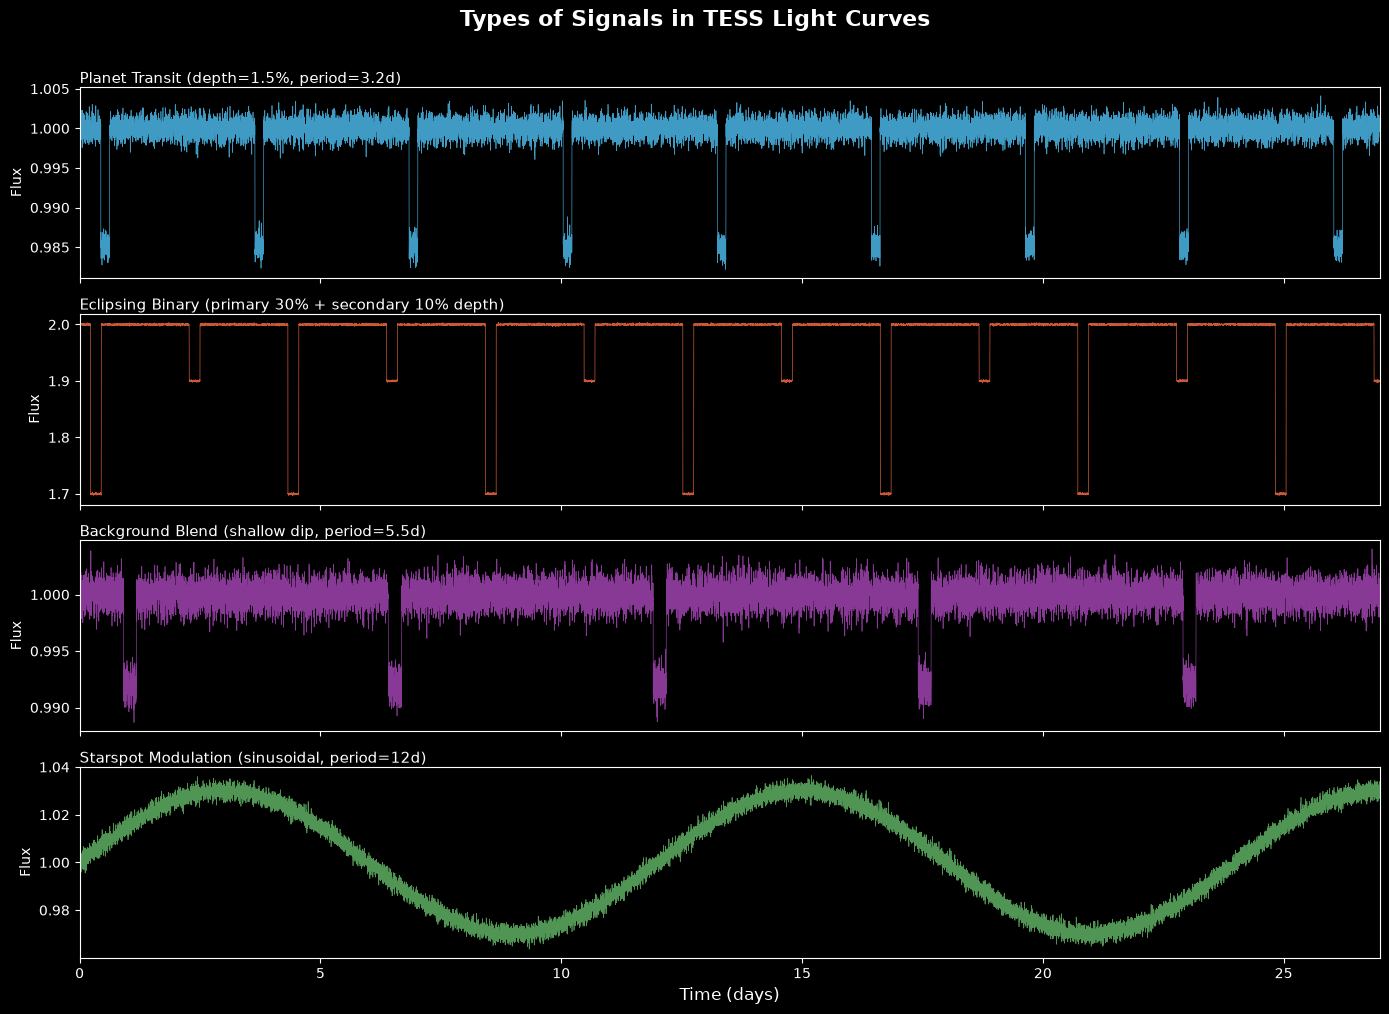

✅ Plot saved to results/figures/signal_types.png


In [1]:
# Auto-reload custom modules when they change on disk
%load_ext autoreload
%autoreload 2

# ============================================================
# Ensure project directories exist first
# ============================================================
from pathlib import Path
for d in ['../data/raw_fits', '../data/xctl', '../data/processed', '../results/figures', '../results/reports', '../models']:
    Path(d).mkdir(parents=True, exist_ok=True)

# ============================================================
# Let's visualise what different signals look like
# This is SIMULATED data — we make it from scratch to illustrate
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Nice plotting style
plt.style.use('dark_background')
COLORS = {'planet': '#4FC3F7', 'binary': '#FF7043', 'blend': '#AB47BC', 'starspot': '#66BB6A'}

# Time array: 27 days at 2-minute cadence
t = np.linspace(0, 27, 27 * 720)
noise = lambda: np.random.normal(0, 0.001, len(t))  # 0.1% Gaussian noise

def transit_box(t, period, t0, depth, duration):
    """Simple box transit model."""
    flux = np.ones(len(t))
    phase = ((t - t0) % period) / period
    in_transit = (phase < duration/period) | (phase > 1 - duration/period/2)
    flux[in_transit] -= depth
    return flux

# Four synthetic light curves (without emoji characters in title fields to prevent Matplotlib glyph warnings)
lc_planet   = transit_box(t, period=3.2, t0=0.5, depth=0.015, duration=0.12) + noise()
lc_binary   = (transit_box(t, period=4.1, t0=0.3, depth=0.30, duration=0.15) +
                transit_box(t, period=4.1, t0=2.35, depth=0.10, duration=0.15)) + noise()
lc_starspot = 1 + 0.03 * np.sin(2*np.pi*t/12) + noise() * 2
lc_blend    = transit_box(t, period=5.5, t0=1.0, depth=0.008, duration=0.18) + noise()

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
fig.suptitle('Types of Signals in TESS Light Curves', fontsize=16, fontweight='bold', y=1.01)

for ax, lc, title, color in zip(
    axes,
    [lc_planet, lc_binary, lc_blend, lc_starspot],
    ['Planet Transit (depth=1.5%, period=3.2d)',
     'Eclipsing Binary (primary 30% + secondary 10% depth)',
     'Background Blend (shallow dip, period=5.5d)',
     'Starspot Modulation (sinusoidal, period=12d)'],
    list(COLORS.values())
):
    ax.plot(t, lc, lw=0.5, color=color, alpha=0.8)
    ax.set_ylabel('Flux', fontsize=10)
    ax.set_title(title, fontsize=11, loc='left', pad=3)
    ax.set_xlim(0, 27)

axes[-1].set_xlabel('Time (days)', fontsize=12)
plt.tight_layout()
plt.savefig('../results/figures/signal_types.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved to results/figures/signal_types.png")

---
## 📚 Concept 3: TIC, xCTL, and Data Sources

### TIC = TESS Input Catalog
A catalog of **~1.7 billion stars** that TESS can observe.  
For each star, it contains:
- **TIC ID**: unique star identifier (like a student roll number)
- **Coordinates**: Right Ascension (RA), Declination (Dec)
- **Tmag**: TESS magnitude (brightness; lower = brighter)
- **Teff**: Effective temperature of the star (in Kelvin)
- **rad**: Stellar radius (in solar radii)
- **mass**: Stellar mass (in solar masses)
- **contratio**: Contamination ratio (how much nearby-star light leaks in)

### xCTL = Exoplanet Candidate Target List
A **curated subset** of ~280,000 of the best exoplanet target stars from the TIC.  
Crucially for us, it includes **labels** from the TESS science team:

| Disposition Code | Meaning | Our ML Label |
|-----------------|---------|-------------|
| `CP` / `KP` | Confirmed Planet | 1 (Planet Transit) |
| `PC` | Planet Candidate | 1 (Planet Transit) |
| `EB` | Eclipsing Binary | 2 (Eclipsing Binary) |
| `FP` | False Positive | 3 (False Positive/Blend) |
| (none) | No signal detected | 0 (No Signal) |

**This is our training data!** We download the xCTL, use its labels, then fetch the actual light curves.

### FITS Files
The actual light curve data is stored in **FITS** (Flexible Image Transport System) format.  
FITS is the universal format for astronomical data — like a ZIP file that contains:
- A **header** with metadata (star name, instrument, observation date)
- A **data table** with columns: TIME, FLUX, FLUX_ERR, QUALITY

The `lightkurve` Python library hides all the FITS complexity from us — it downloads and parses FITS files automatically.


In [2]:
# ============================================================
# Let's download a REAL TESS light curve!
# Target: WASP-121 — a famous "hot Jupiter" exoplanet host
# TIC ID: 261136679
# ============================================================

import lightkurve as lk

print("🔭 Searching MAST for TIC 261136679 (WASP-121)...")

# Search for available TESS data
search = lk.search_lightcurve("TIC 261136679", mission="TESS", cadence="short")
print(f"Found {len(search)} light curve(s):")
print(search)

print("\n⬇️  Downloading first sector...")
lc = search[0].download()

print(f"\n✅ Downloaded! Light curve info:")
print(f"   Type: {type(lc)}")
print(f"   Columns: {lc.colnames}")
print(f"   Number of data points: {len(lc)}")
print(f"   Time range: {lc.time[0].value:.2f} to {lc.time[-1].value:.2f} BTJD")
print(f"   Duration: {lc.time[-1].value - lc.time[0].value:.1f} days")

🔭 Searching MAST for TIC 261136679 (WASP-121)...


Found 26 light curve(s):
SearchResult containing 26 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 01 2018   SPOC     120   261136679      0.0
  1 TESS Sector 04 2018   SPOC     120   261136679      0.0
  2 TESS Sector 08 2019   SPOC     120   261136679      0.0
  3 TESS Sector 11 2019   SPOC     120   261136679      0.0
  4 TESS Sector 12 2019   SPOC     120   261136679      0.0
  5 TESS Sector 13 2019   SPOC     120   261136679      0.0
  6 TESS Sector 27 2020   SPOC     120   261136679      0.0
  7 TESS Sector 28 2020   SPOC     120   261136679      0.0
  8 TESS Sector 31 2020   SPOC     120   261136679      0.0
  9 TESS Sector 34 2021   SPOC     120   261136679      0.0
 10 TESS Sector 38 2021   SPOC     120   261136679      0.0
 11 TESS Sector 39 2021   SPOC     120   261136679      0.0
 12 TESS Sector 61 2023   SPOC  

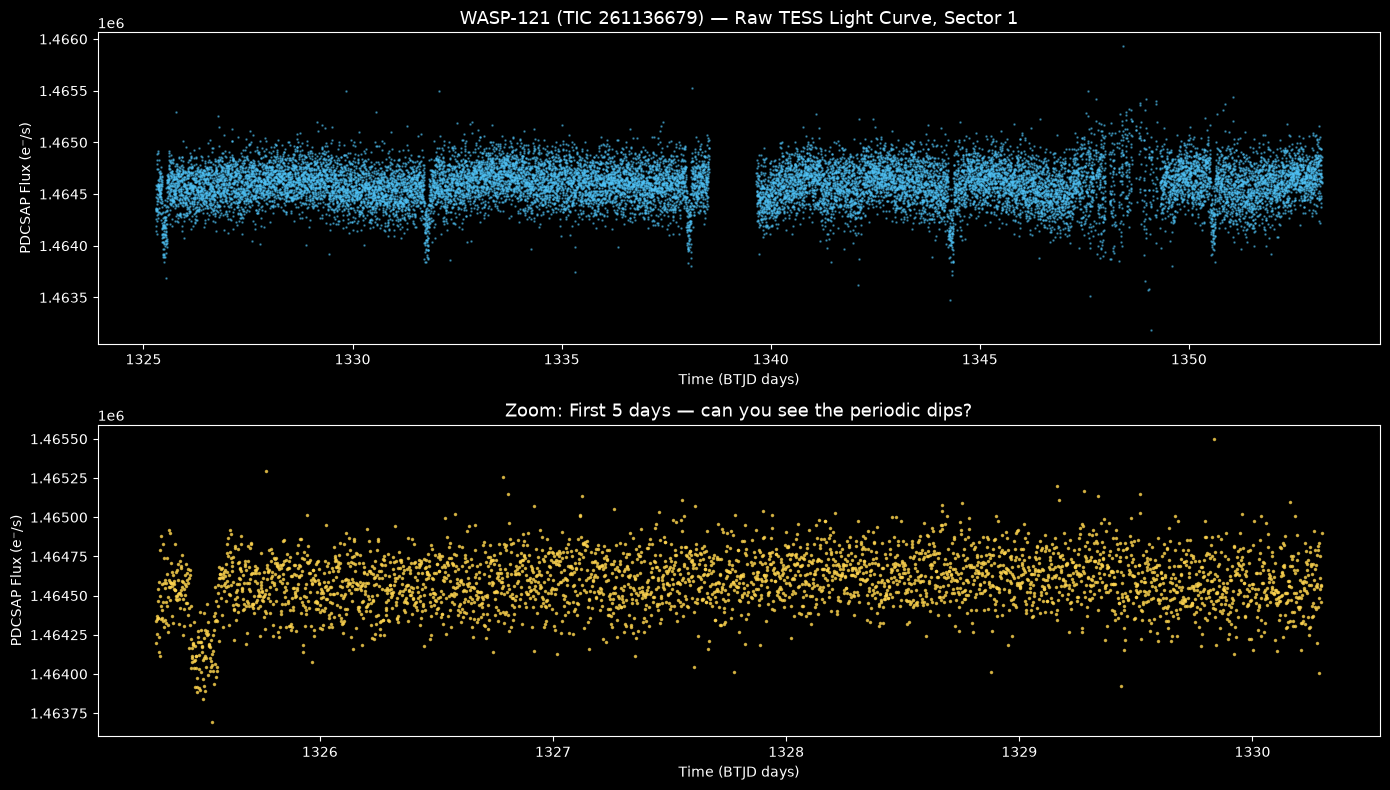

Transit period is ~1.27 days — you should see dips every ~1.27 days!


In [3]:
# ============================================================
# Let's look at the RAW data before any processing
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

time_raw = lc.time.value
flux_raw = lc.pdcsap_flux.value

# Top: full raw light curve
axes[0].plot(time_raw, flux_raw, 'o', ms=0.8, alpha=0.5, color='#4FC3F7')
axes[0].set_xlabel('Time (BTJD days)')
axes[0].set_ylabel('PDCSAP Flux (e⁻/s)')
axes[0].set_title('WASP-121 (TIC 261136679) — Raw TESS Light Curve, Sector 1', fontsize=13)

# Zoom into first 5 days to see individual transits
mask = (time_raw - time_raw[0]) < 5
axes[1].plot(time_raw[mask], flux_raw[mask], 'o', ms=1.5, alpha=0.7, color='#FFD54F')
axes[1].set_xlabel('Time (BTJD days)')
axes[1].set_ylabel('PDCSAP Flux (e⁻/s)')
axes[1].set_title('Zoom: First 5 days — can you see the periodic dips?', fontsize=13)

plt.tight_layout()
plt.savefig('../results/figures/wasp121_raw.png', dpi=150, bbox_inches='tight')
plt.show()
print("Transit period is ~1.27 days — you should see dips every ~1.27 days!")

---
## 📚 Concept 4: What is PDCSAP Flux?

You'll notice the light curve has a column called **`pdcsap_flux`**.

TESS actually produces two types of flux measurements:

| Column | Full Name | What it is |
|--------|-----------|------------|
| `sap_flux` | Simple Aperture Photometry | Raw pixel sum — lots of spacecraft systematics |
| `pdcsap_flux` | Pre-search Data Conditioning SAP | Corrected for satellite drift, focus changes, etc. |

**We always use `pdcsap_flux`** because the TESS pipeline has already removed most instrument artifacts for us.

However, some stellar variability still remains — which is why we need our own detrending step (Phase 2).


In [4]:
# ============================================================
# 🔬 EXERCISE: Explore the light curve data structure
# Run this cell to understand what we're working with
# ============================================================

import pandas as pd
import numpy as np

# Convert to pandas DataFrame for easy exploration
df = lc.to_pandas()

print("=" * 60)
print("LIGHT CURVE AS A PANDAS DATAFRAME")
print("=" * 60)
print(f"Shape: {df.shape}  ({df.shape[0]:,} rows × {df.shape[1]} columns)")
print(f"\nFirst 5 rows:")
print(df[['pdcsap_flux', 'pdcsap_flux_err', 'quality']].head())

print(f"\nBasic statistics of PDCSAP flux:")
flux = df['pdcsap_flux'].dropna()
print(f"  Min:    {flux.min():,.1f} e⁻/s")
print(f"  Max:    {flux.max():,.1f} e⁻/s")
print(f"  Median: {flux.median():,.1f} e⁻/s")
print(f"  Std:    {flux.std():,.1f} e⁻/s ({100*flux.std()/flux.median():.3f}% of median)")
print(f"  NaN count: {df['pdcsap_flux'].isna().sum()} ({100*df['pdcsap_flux'].isna().mean():.1f}% of data)")

print(f"\nQuality flags > 0 (bad cadences): {(df['quality'] > 0).sum():,}")
print(f"Fraction of bad cadences: {100*(df['quality'] > 0).mean():.1f}%")

print("\n💡 Notice: the flux is in units of electrons/second.")
print("   After normalising (dividing by median), it becomes ~1.0")
print("   A 1% transit appears as a dip from 1.0000 to 0.9900")

LIGHT CURVE AS A PANDAS DATAFRAME
Shape: (18264, 23)  (18,264 rows × 23 columns)

First 5 rows:
             pdcsap_flux  pdcsap_flux_err  quality
time                                              
1325.296960  1464195.625       130.367188        0
1325.298349  1464336.500       130.358093        0
1325.299738  1464348.500       130.359314        0
1325.301127  1464367.375       130.350082        0
1325.302516  1464256.000       130.348358        0

Basic statistics of PDCSAP flux:
  Min:    1,463,186.4 e⁻/s
  Max:    1,465,927.6 e⁻/s
  Median: 1,464,602.2 e⁻/s
  Std:    197.2 e⁻/s (0.013% of median)
  NaN count: 0 (0.0% of data)

Quality flags > 0 (bad cadences): 0
Fraction of bad cadences: 0.0%

💡 Notice: the flux is in units of electrons/second.
   After normalising (dividing by median), it becomes ~1.0
   A 1% transit appears as a dip from 1.0000 to 0.9900


---
## 📚 Concept 5: The ML Pipeline Overview

Here's the full journey from raw data to planet detection:

```
RAW FITS FILE
    │
    ▼  Phase 2: Preprocessing
CLEAN LIGHT CURVE (detrended, normalised, sigma-clipped)
    │
    ▼  Phase 3: Transit Detection (BLS)
BEST-FIT PERIOD + TRANSIT PARAMS + SNR
    │
    ├──▶  Phase 4: Feature Extraction  ──▶  FEATURE VECTOR (30 numbers)
    │                                            │
    │                                            ▼  Phase 5: Random Forest
    │                                       CLASSIFICATION (Planet/EB/FP/None)
    │                                       CONFIDENCE SCORE
    │
    └──▶  Phase 6: CNN (raw phase-folded LC as input)
              └──▶  CLASSIFICATION + CONFIDENCE (deep learning approach)
    │
    ▼  Phase 7: Parameter Estimation (Batman model)
ORBITAL PERIOD ± error
TRANSIT DEPTH  ± error
TRANSIT DURATION ± error
    │
    ▼  Phase 8: Visualization + Report
4-PANEL DIAGNOSTIC PLOT + JSON REPORT
```

The key insight: we have **two parallel classification approaches**:
1. **Random Forest** on handcrafted features (Phase 5) — interpretable, fast
2. **CNN** on raw phase-folded curves (Phase 6) — powerful, deep learning

We combine them for a final confidence score!


In [5]:
# ============================================================
# 🔬 EXERCISE: Look at the xCTL — our training labels
# Run this AFTER downloading the xCTL in notebook 01
# ============================================================

from pathlib import Path

xctl_path = Path('../data/xctl/exo_CTL_08.01.csv')

if xctl_path.exists():
    import pandas as pd
    print("Loading xCTL...")
    df_xctl = pd.read_csv(xctl_path, nrows=5000, low_memory=False)
    
    print(f"Shape (first 5000 rows): {df_xctl.shape}")
    print(f"\nColumns:")
    for i, col in enumerate(df_xctl.columns):
        print(f"  [{i:3d}] {col}")
    
    print(f"\nFirst 3 rows (selected columns):")
    key_cols = [c for c in df_xctl.columns if any(k in c.lower() 
                for k in ['tic', 'id', 'tmag', 'disp', 'teff', 'rad'])]
    print(df_xctl[key_cols[:8]].head(3).to_string())
else:
    print("⚠️  xCTL not yet downloaded. Run notebook 01 first!")
    print("Or run:")
    print("   import sys; sys.path.insert(0, '..')")
    print("   from src.download import download_xctl")
    print("   download_xctl()")

Loading xCTL...
Shape (first 5000 rows): (5000, 4)

Columns:
  [  0] 80423805
  [  1] 1.9230157985751999E-4
  [  2] planetcandidate
  [  3] 80

First 3 rows (selected columns):
   planetcandidate
0    cooldwarfs_v8
1    cooldwarfs_v8
2  planetcandidate


---
## ✅ Notebook 00 Summary

**What you learned:**
- TESS measures star brightness every 2 minutes for 27-day sectors
- A **light curve** = brightness vs. time plot
- Transit signals are tiny dips (<2%) that repeat periodically
- FITS files store the time-series data; `lightkurve` reads them for us
- **xCTL** = our labeled training dataset (280,000 stars with dispositions)
- **TIC** = star metadata catalog (temperature, radius, contamination, etc.)

**What you ran:**
- Your first `lightkurve` download of a real TESS light curve (WASP-121!)
- Explored the data structure with pandas
- Visualised what different signal types look like

**Next:** Notebook `01_download_data.ipynb` — building our training dataset
